#### AI 헬스케어 첫번째 미니 프로젝트 “흡연 여부 데이터 분석을 통한 건강 인사이트 도출” 에 오신 여러분 환영합니다.
이번 프로젝트에서는 흡연여부를 판단하는 데이터를 가지고 시각화 및 가설을 판별해보려고 합니다.


A-Z로 진행되는 만큼 천천히 따라해보세요!

#### 개인과제
- 데이터 구조, 분포 확인, 전처리 : 1.1_흡연여부데이터
- 데이터 간 관계 가설 수립 및 검증 : 1.2_데이터분석



### 흡연여부데이터 분석하기
최근 여러 기관에서는 흡연이 개인의 건강에 미치는 영향을 정확히 파악하고,
이를 기반으로 예방 중심의 건강관리 정책을 수립하려는 노력을 강화하고 있습니다.

하지만 “흡연 여부”를 직접 조사하는 것은 현실적으로 쉽지 않습니다.
이에 따라, 건강검진 데이터를 통해 흡연 여부를 데이터 기반으로 추정하고,
흡연자와 비흡연자 간의 생체·건강 지표 차이를 검증하려는 프로젝트가 시작되었습니다.

여러분은 이 프로젝트의 데이터 분석가이자 AI 엔지니어로 참여하게 되었습니다.
주어진 데이터에는 개인의 건강검진 결과(혈압, 혈당, 콜레스테롤, BMI 등)와
흡연 여부(label = 0 또는 1)가 포함되어 있습니다.

이제 여러분의 역할은 흡연 여부 데이터의 특성을 분석하고 시각화하며,
통계적 검정을 통해 변수 간 관계를 규명하는 것입니다.
시작해봅시다 !

#### 🎯 프로젝트 목표

	•	흡연자와 비흡연자 간의 건강 지표 차이 분석
	•	주요 변수들의 분포, 상관관계, 통계적 유의성 검증
	•	시각화를 통한 데이터 인사이트 도출
	•	추후 흡연 여부 예측 모델 개발을 위한 기초 분석 기반 마련




---



### 데이터 알아보기

#### 데이터 안내
- 'smoking_health_data.csv'
- 건강 정보 데이터


## 1. 데이터 불러오기
### 모든 데이터 분석의 시작은 '데이터 불러오기' 부터 입니다!
### 데이터 프레임을 불러오고 변수로 저장해봅시다!
- csv : pd.read_csv("파일이름. csv")
- txt : pd.read_csv("파일이름. csv", sep="구분자")
- xlsx : pd.read_excel('파일이름.xlsx')
- pickle : pd.read_pickle("파일이름.pkl")

[참고] pickle은 파이썬의 모든 객체를 파일로 저장할 수 있는 방법으로 DataFrame,List,Dict 등 모든 객체 저장 가능(특히 sklearn라이브러리를 통해 모델을 학습시키고, 저장할 때 많이 사용됩니다)

In [ ]:
# 필요한 라이브러리들 불러오기

# 데이터 분석 및 처리용 라이브러리
import pandas as pd
import numpy as np

# 시각화 라이브러리
import matplotlib.pyplot as plt
import seaborn as sns

# 통계 분석 라이브러리
from scipy import stats


In [ ]:
import platform
import matplotlib.pyplot as plt

KOREAN_FONT = 'AppleGothic' if platform.system() == 'Darwin' else 'AppleGothic'
plt.rc('font', family=KOREAN_FONT)
plt.rcParams['axes.unicode_minus'] = False

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 1 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/n

In [ ]:
import matplotlib.pyplot as plt
plt.rc('font', family='AppleGothic')
plt.rcParams['axes.unicode_minus'] =False

##### [TODO] 데이터 로딩
- Pandas 라이브러리를 활용해서 'smoking_health_data.csv' 파일을 'health_data' 변수에 저장하세요.
- 데이터 프레임의 크기를 확인해보세요. (shape)

In [ ]:
# 아래에 실습코드를 작성하고 결과를 확인합니다.
#CSV 파일 불러오기
health_data = pd.read_csv("../data/smoking_health_data.csv")

In [ ]:
# 아래에 실습코드를 작성하고 결과를 확인합니다.
# 데이터 크기 확인
print(f"데이터 크기: {health_data.shape}")
health_data.head()

데이터 크기: (7000, 18)


,ID,나이,키(cm),몸무게(kg),BMI,시력,충치,공복 혈당,혈압,중성 지방,혈청 크레아티닌,콜레스테롤,고밀도지단백,저밀도지단백,헤모글로빈,요 단백,간 효소율,label
0,TRAIN_0000,35,170,70,24.22,1.10,1,98.0,40.0,80.0,1.3,211,75,120,15.9,1,1.53,1
1,TRAIN_0001,40,150,55,24.44,1.00,0,173.0,39.0,104.0,0.6,251,46,184,11.8,1,1.45,0
2,TRAIN_0002,60,170,50,17.30,0.75,0,96.0,40.0,61.0,0.8,144,43,89,15.3,1,1.04,0
3,TRAIN_0003,40,150,45,20.00,0.50,0,92.0,40.0,46.0,0.7,178,66,110,13.4,1,1.18,0
4,TRAIN_0004,55,155,65,27.06,NaN,0,87.0,42.0,95.0,0.9,232,62,151,13.8,1,1.32,0


## 기본 정보 확인 및 클렌징
- 데이터 클렌징이란 ? 결측치, 이상치 등을 제거하여 데이터 분석 결과가 왜곡 되는 문제를 방지하기 위한 정제 과정입니다.

##### [TODO] 기본 정보 확인하기
- 'health_data' 데이터의 정보를 확인해보세요.
- 'describe', 'info', 'head', 'tail' 등 전부 활용해봅시다.

In [ ]:
# 아래에 실습코드를 작성하고 결과를 확인합니다.
print(f"총 {len(health_data)}명의 환자 데이터")

총 7000명의 환자 데이터


In [ ]:
# 아래에 실습코드를 작성하고 결과를 확인합니다.
health_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 18 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   ID        7000 non-null   object 
 1   나이        7000 non-null   int64  
 2   키(cm)     7000 non-null   int64  
 3   몸무게(kg)   7000 non-null   int64  
 4   BMI       7000 non-null   float64
 5   시력        6860 non-null   float64
 6   충치        7000 non-null   int64  
 7   공복 혈당     6860 non-null   float64
 8   혈압        6860 non-null   float64
 9   중성 지방     6860 non-null   float64
 10  혈청 크레아티닌  7000 non-null   float64
 11  콜레스테롤     7000 non-null   int64  
 12  고밀도지단백    7000 non-null   int64  
 13  저밀도지단백    7000 non-null   int64  
 14  헤모글로빈     7000 non-null   float64
 15  요 단백      7000 non-null   int64  
 16  간 효소율     7000 non-null   float64
 17  label     7000 non-null   int64  
dtypes: float64(8), int64(9), object(1)
memory usage: 984.5+ KB


In [ ]:
# 아래에 실습코드를 작성하고 결과를 확인합니다.
health_data.describe() # 통계랑, 평균, 표준편차, 최솟값, 최대값 확인

,나이,키(cm),몸무게(kg),BMI,시력,충치,공복 혈당,혈압,중성 지방,혈청 크레아티닌,콜레스테롤,고밀도지단백,저밀도지단백,헤모글로빈,요 단백,간 효소율,label
count,7000.000000,7000.000000,7000.000000,7000.000000,6860.000000,7000.000000,6860.000000,6860.000000,6860.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000
mean,43.973571,164.781429,65.932857,24.144423,1.011414,0.227429,99.307289,45.555102,127.028134,0.884900,197.276571,57.355429,115.346857,14.631914,1.083857,1.144696,0.367286
std,12.063793,9.170213,12.978702,3.501945,0.430137,0.419202,21.190058,8.831564,73.219161,0.241523,36.306494,14.506945,41.788153,1.540907,0.392051,0.432735,0.482100
min,20.000000,135.000000,30.000000,14.270000,0.100000,0.000000,57.000000,14.000000,21.000000,0.100000,86.000000,18.000000,1.000000,4.900000,1.000000,0.140000,0.000000
25%,35.000000,160.000000,55.000000,21.600000,0.800000,0.000000,89.000000,40.000000,74.000000,0.800000,173.000000,47.000000,92.000000,13.600000,1.000000,0.840000,0.000000
50%,40.000000,165.000000,65.000000,23.880000,1.000000,0.000000,96.000000,45.000000,107.000000,0.900000,195.000000,55.000000,113.000000,14.800000,1.000000,1.100000,0.000000
75%,50.000000,170.000000,75.000000,26.120000,1.200000,0.000000,104.000000,50.000000,161.000000,1.000000,219.000000,66.000000,136.000000,15.700000,1.000000,1.380000,1.000000
max,85.000000,190.000000,130.000000,42.450000,9.900000,1.000000,386.000000,91.000000,399.000000,10.000000,395.000000,157.000000,1340.000000,20.900000,5.000000,5.670000,1.000000


In [ ]:
health_data.head()



,ID,나이,키(cm),몸무게(kg),BMI,시력,충치,공복 혈당,혈압,중성 지방,혈청 크레아티닌,콜레스테롤,고밀도지단백,저밀도지단백,헤모글로빈,요 단백,간 효소율,label
0,TRAIN_0000,35,170,70,24.22,1.10,1,98.0,40.0,80.0,1.3,211,75,120,15.9,1,1.53,1
1,TRAIN_0001,40,150,55,24.44,1.00,0,173.0,39.0,104.0,0.6,251,46,184,11.8,1,1.45,0
2,TRAIN_0002,60,170,50,17.30,0.75,0,96.0,40.0,61.0,0.8,144,43,89,15.3,1,1.04,0
3,TRAIN_0003,40,150,45,20.00,0.50,0,92.0,40.0,46.0,0.7,178,66,110,13.4,1,1.18,0
4,TRAIN_0004,55,155,65,27.06,NaN,0,87.0,42.0,95.0,0.9,232,62,151,13.8,1,1.32,0


##### [TODO] 위 데이터에서 BMI를 기준으로 체중 상태 구분 칼럼을 만들어보세요.
- BMI 구간을 기준으로 건강상태를 분류해볼까요 ?
- 저체중 (<18.5)
- 정상 (<25)
- 과체중 (<30)
- 비만 (>=30)


In [ ]:
# 아래에 실습코드를 작성하고 결과를 확인합니다.

bins = [0, 18.5, 25, 30, 50]
labels = ["저체중", "정상", "과체중", "비만"]
health_data["체중 상태"] = pd.cut(health_data["BMI"], bins=bins, labels=labels, right=True)

health_data.head()

,ID,나이,키(cm),몸무게(kg),BMI,시력,충치,공복 혈당,혈압,중성 지방,혈청 크레아티닌,콜레스테롤,고밀도지단백,저밀도지단백,헤모글로빈,요 단백,간 효소율,label,체중 상태
0,TRAIN_0000,35,170,70,24.22,1.10,1,98.0,40.0,80.0,1.3,211,75,120,15.9,1,1.53,1,정상
1,TRAIN_0001,40,150,55,24.44,1.00,0,173.0,39.0,104.0,0.6,251,46,184,11.8,1,1.45,0,정상
2,TRAIN_0002,60,170,50,17.30,0.75,0,96.0,40.0,61.0,0.8,144,43,89,15.3,1,1.04,0,저체중
3,TRAIN_0003,40,150,45,20.00,0.50,0,92.0,40.0,46.0,0.7,178,66,110,13.4,1,1.18,0,정상
4,TRAIN_0004,55,155,65,27.06,NaN,0,87.0,42.0,95.0,0.9,232,62,151,13.8,1,1.32,0,과체중


##### [TODO] 위 데이터에서 '나이'를 기준으로 나이대를 구분하는 칼럼을 만들어보세요.

'나이' 구간을 기준으로 나이대를 분류해볼까요 ?
- 30대 이하
- 30~50대
- 50~70대
- 70대 이상

In [ ]:
# 아래에 실습코드를 작성하고 결과를 확인합니다.
bins = [0, 30, 49, 69, 100]
labels = ["청년(-30)", "중년(31-49)", "장년(50-69)", "노년(70-)"]
health_data["나이대"] = pd.cut(health_data["나이"], bins=bins, labels=labels, right=True)

health_data.head()

,ID,나이,키(cm),몸무게(kg),BMI,시력,충치,공복 혈당,혈압,중성 지방,혈청 크레아티닌,콜레스테롤,고밀도지단백,저밀도지단백,헤모글로빈,요 단백,간 효소율,label,체중 상태,나이대
0,TRAIN_0000,35,170,70,24.22,1.10,1,98.0,40.0,80.0,1.3,211,75,120,15.9,1,1.53,1,정상,중년(31-49)
1,TRAIN_0001,40,150,55,24.44,1.00,0,173.0,39.0,104.0,0.6,251,46,184,11.8,1,1.45,0,정상,중년(31-49)
2,TRAIN_0002,60,170,50,17.30,0.75,0,96.0,40.0,61.0,0.8,144,43,89,15.3,1,1.04,0,저체중,장년(50-69)
3,TRAIN_0003,40,150,45,20.00,0.50,0,92.0,40.0,46.0,0.7,178,66,110,13.4,1,1.18,0,정상,중년(31-49)
4,TRAIN_0004,55,155,65,27.06,NaN,0,87.0,42.0,95.0,0.9,232,62,151,13.8,1,1.32,0,과체중,장년(50-69)


##### [TODO] 결측치 처리
결측치를 확인 했다면 분석 결과가 왜곡될 수 있으므로 반드시 확인하고 적절히 처리해야 합니다!

평균, 중앙값, 최빈값으로 채우는 것이 일반적이지만, 해당 변수의 의미를 고려해 선택해야 합니다.

예: 혈압은 중앙값, 시력은 최빈값, 나이대별 중성지방은 그룹 평균으로 채우기, 공복 혈당은 평균으로 채우기

In [ ]:
# 아래에 실습코드를 작성하고 결과를 확인합니다.
#결측치 확인
missing_check = health_data.isnull().sum()
print('결측치 확인')

missing_check

결측치 확인


,0
ID,0
나이,0
키(cm),0
몸무게(kg),0
BMI,0
시력,140
충치,0
공복 혈당,140
혈압,140
중성 지방,140


In [ ]:
# 아래에 실습코드를 작성하고 결과를 확인합니다.
#결측치 처리

# 1 혈압(중앙값으로 대체)
bp_midian = health_data['혈압'].median()
health_data['혈압'] = health_data['혈압'].fillna(bp_midian)

# 1-1 결측치 재확인
print(f'혈압 현재 결측치:{health_data['혈압'].isnull().sum()}개')

# 2 시력(최빈값으로 대체)
vision_mode = health_data['시력'].mode()[0]
health_data['시력'] = health_data['시력'].fillna(vision_mode)

# 2-2 결측치 재확인
print(f'시력 현재 결측치:{health_data['시력'].isnull().sum()}개')




혈압 현재 결측치:0개
시력 현재 결측치:0개


In [ ]:
#나이대별 중성지방(그룹 평균 대체)
# 3. 나이대별로 그룹 나누기
# 3-1 나이대별 중성지방 평균
health_data['중성 지방'] = health_data['중성 지방'].fillna(
    health_data.groupby('나이대', observed=True)['중성 지방'].transform('mean')
)

# 결측치 재확인
# 2-2 결측치 재확인
print(f'중성지방 현재 결측치:{health_data['중성 지방'].isna().sum()}개')

중성지방 현재 결측치:0개


In [ ]:
# 4. 공복 혈당(평균으로 채우기)

# 1 혈압(중앙값으로 대체)
fbs_mean = health_data['공복 혈당'].mean()
health_data['공복 혈당'] = health_data['공복 혈당'].fillna(fbs_mean)

# 1-1 결측치 재확인
print(f'공복 혈당 현재 결측치:{health_data['공복 혈당'].isnull().sum()}개')

# 흡연 여부 컬럼 (이후 시각화에서 사용)
health_data["흡연 여부"] = health_data['label'].replace({0: "비흡연", 1: "흡연"})

공복 혈당 현재 결측치:0개


## 이상치 탐색
IQR 기준으로 주요 변수의 이상치 분포를 확인합니다.

In [ ]:
# 주요 변수 이상치 탐색
key_vars = ['BMI', '혈압', '공복 혈당', '중성 지방', '헤모글로빈', '콜레스테롤']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, var in enumerate(key_vars):
    Q1 = health_data[var].quantile(0.25)
    Q3 = health_data[var].quantile(0.75)
    IQR = Q3 - Q1
    outlier_count = ((health_data[var] < Q1 - 1.5 * IQR) | (health_data[var] > Q3 + 1.5 * IQR)).sum()

    axes[i].boxplot(health_data[var].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor='lightblue', alpha=0.7))
    axes[i].set_title(f'{var}\n(이상치 {outlier_count}개 / {outlier_count/len(health_data)*100:.1f}%)')
    axes[i].set_ylabel(var)

plt.suptitle('주요 변수별 이상치 탐색 (IQR 기준)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../images/01_eda/01_이상치_탐색.png', dpi=150, bbox_inches='tight')
plt.show()

## 흡연 여부별 주요 건강 지표 요약
흡연/비흡연 그룹 간 수치 차이를 한눈에 비교합니다.

In [ ]:
# 흡연 여부별 그룹 통계 요약
summary_vars = ['BMI', '혈압', '공복 혈당', '중성 지방', '헤모글로빈', '콜레스테롤']

summary = (
    health_data.groupby('흡연 여부')[summary_vars]
    .agg(['mean', 'median', 'std'])
    .round(2)
)

# 보기 좋게 멀티인덱스 컬럼 정리
summary.columns = [f'{var}_{stat}' for var, stat in summary.columns]
summary.T

## 3. 데이터 분석하기

KeyPoint : 데이터의 형태를 살펴보고 다양한 분석기법을 통해 모델링에 적합하도록 정제요소를 선별할 수 있다.
- 데이터들의 패턴 탐색
- 변수들간의 관계 파악

##### [TODO] 데이터 분포 알아보기
- 다양한 변수를 기준으로 그래프를 그려보고 변수 인사이트를 도출해보세요.
- 데이터의 형태와 분포를 시각화하면 이상치, 극단값, 데이터 패턴을 쉽게 파악할 수 있습니다 !

# 흡연 여부 분포

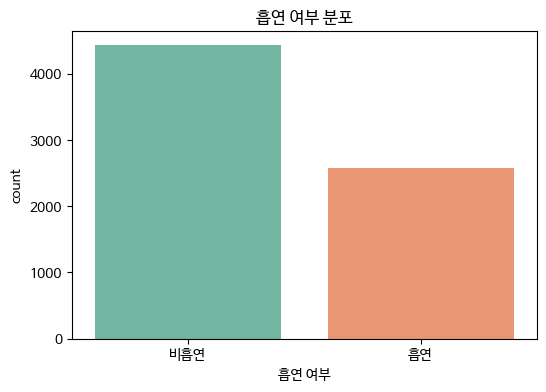

In [ ]:
# 아래에 실습코드를 작성하고 결과를 확인합니다.
# 흡연 여부 분포
plt.figure(figsize=(6,4))

sns.countplot(data= health_data, x="label",
              hue="label",
              legend=False,
              palette='Set2'
              )

plt.title('흡연 여부 분포')
plt.xlabel('흡연 여부')
plt.ylabel('count')
plt.xticks([0, 1], ['비흡연', '흡연'])         # X축 눈금: 리스트 변수 활용하여 변경

plt.savefig('../images/01_eda/02_흡연여부_분포.png', dpi=150, bbox_inches='tight')
plt.show()  # 차트를 화면에 출력

# 흡연 여부에 따른 나이대별 혈압 분포

Text(0, 0.5, 'BMI 수치')

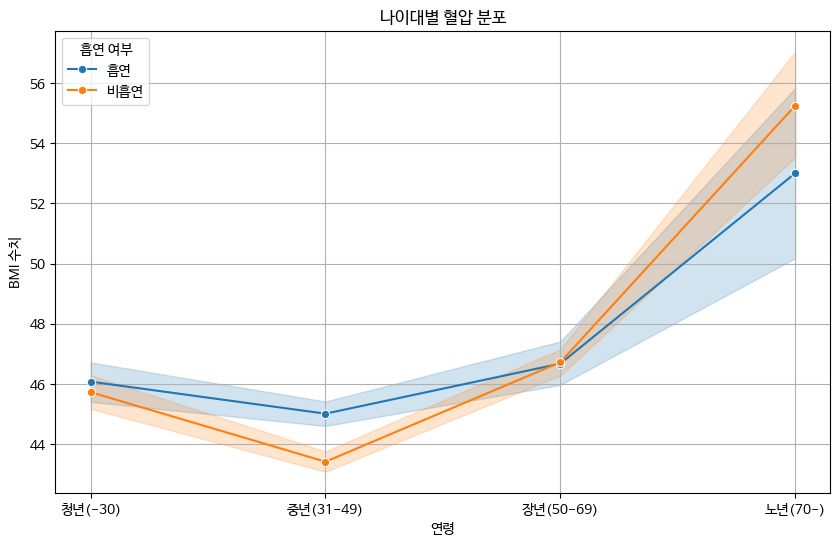

In [ ]:
#흡연 여부에 따른 나이대별 혈압 분포
plt.figure(figsize=(10, 6))

sns.lineplot(data=health_data, x='나이대', y='혈압', hue='흡연 여부', marker='o')
plt.title('나이대별 흡연 여부에 따른 혈압 변화 추세')
plt.xlabel('연령')
plt.ylabel('혈압 (mmHg)')
plt.grid(True)
plt.savefig('../images/01_eda/03_나이대별_혈압_추세.png', dpi=150, bbox_inches='tight')
plt.show()

#흡연 여부에 따른 나이대별 평균 혈당 비교

Text(0.5, 1.0, '나이대별 평균 혈당 비교')

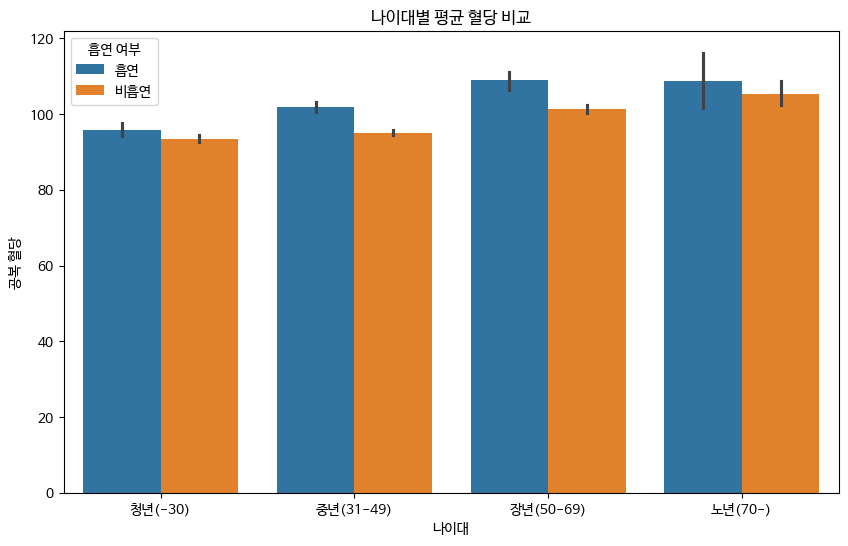

In [ ]:
#흡연 여부에 따른 나이대별 평균 혈당 비교
plt.figure(figsize=(10, 6))

sns.barplot(data=health_data, x='나이대', y='공복 혈당', hue='흡연 여부')
plt.title('나이대별 평균 혈당 비교')
plt.savefig('../images/01_eda/04_나이대별_혈당_비교.png', dpi=150, bbox_inches='tight')
plt.show()


# 나이대별 BMI분포

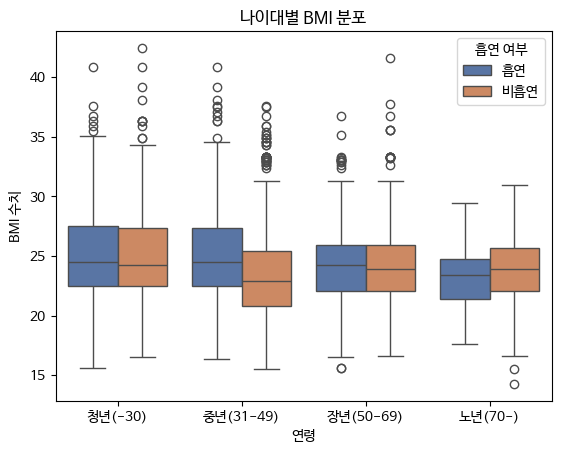

In [ ]:
# 아래에 실습코드를 작성하고 결과를 확인합니다.
# 나이대별 BMI분포
health_data["흡연 여부"] = health_data['label'].replace({0: "비흡연", 1:  "흡연"})

# 2. 나이대별 bmi 히스토그램 그리기
sns.boxplot(data=health_data, x="나이대",
             y='BMI',
             hue="흡연 여부",
             palette="deep")

# 3. 제목과 축 라벨 추가
plt.title('나이대별 BMI 분포')
plt.xlabel('연령')
plt.ylabel('BMI 수치')

# 4. 그래프 출력
plt.savefig('../images/01_eda/05_나이대별_BMI_분포.png', dpi=150, bbox_inches='tight')
plt.show()


# 흡연 여부 데이터의 주요 의료 변수들 간 상관관계 히트맵

In [ ]:
#상관관계 히트맵
# 흡연 여부 데이터의 주요 의료 변수들 간 상관관계 분석
biometric_data = [
    "label", "BMI", "혈압", "공복 혈당",
    "중성 지방", "콜레스테롤",
    "고밀도지단백", "저밀도지단백",
    "혈청 크레아티닌", "헤모글로빈",
    "간 효소율", "요 단백"
]

correlation_matrix = health_data[biometric_data].corr()  # 피어슨 상관계수 계산

correlation_matrix


,label,BMI,혈압,공복 혈당,중성 지방,콜레스테롤,고밀도지단백,저밀도지단백,혈청 크레아티닌,헤모글로빈,간 효소율,요 단백
label,1.000000,0.126438,0.018961,0.110636,0.245272,-0.009176,-0.180835,-0.032728,0.197585,0.402002,-0.183779,-0.004987
BMI,0.126438,1.000000,0.163847,0.150908,0.336766,0.092870,-0.344352,0.083688,0.142320,0.273406,-0.376040,0.023603
혈압,0.018961,0.163847,1.000000,0.089595,0.082426,-0.013494,-0.048247,-0.016506,0.015251,0.046319,-0.048608,0.014784
공복 혈당,0.110636,0.150908,0.089595,1.000000,0.216141,0.002630,-0.119630,-0.003659,0.035750,0.112458,-0.125994,0.123898
중성 지방,0.245272,0.336766,0.082426,0.216141,1.000000,0.234534,-0.423167,0.006601,0.107500,0.274542,-0.288511,0.042700
콜레스테롤,-0.009176,0.092870,-0.013494,0.002630,0.234534,1.000000,0.167032,0.715751,-0.008888,0.079272,-0.081216,-0.016034
고밀도지단백,-0.180835,-0.344352,-0.048247,-0.119630,-0.423167,0.167032,1.000000,-0.052307,-0.171014,-0.251819,0.290684,-0.031795
저밀도지단백,-0.032728,0.083688,-0.016506,-0.003659,0.006601,0.715751,-0.052307,1.000000,0.030314,0.074842,-0.080954,-0.017491
혈청 크레아티닌,0.197585,0.142320,0.015251,0.035750,0.107500,-0.008888,-0.171014,0.030314,1.000000,0.340487,-0.141611,0.064828
헤모글로빈,0.402002,0.273406,0.046319,0.112458,0.274542,0.079272,-0.251819,0.074842,0.340487,1.000000,-0.377858,0.021680


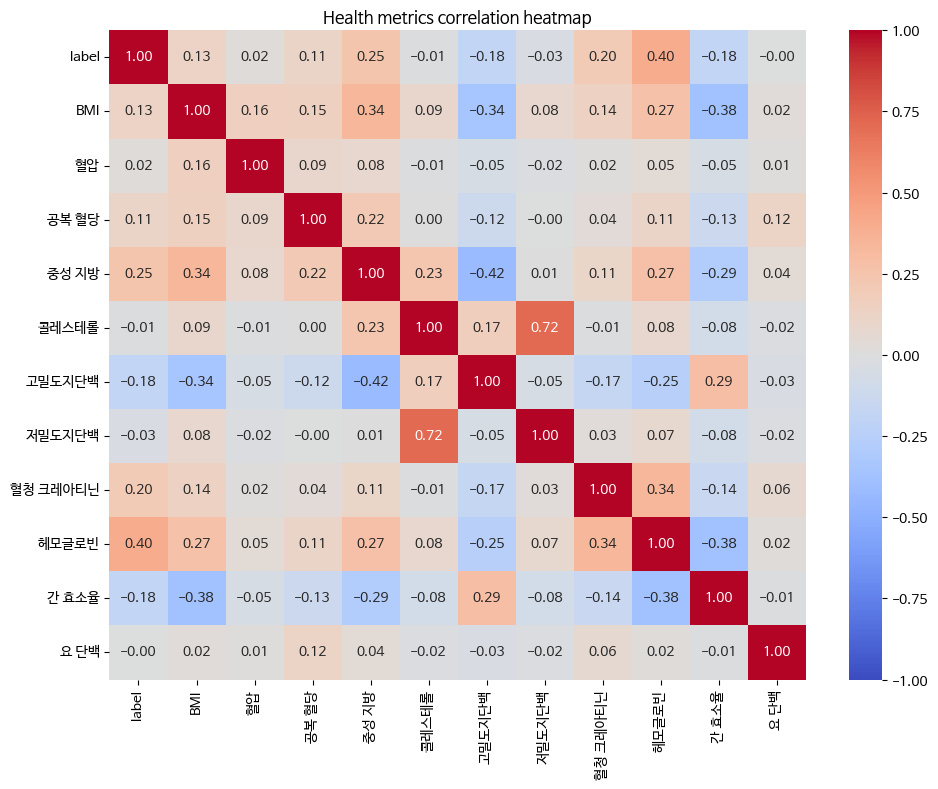

In [ ]:
#히트맵 차트
#흡연자의료 변수들 간의 관계

plt.figure(figsize=(10, 8))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    vmin=-1, vmax=1,
    cmap="coolwarm"
)
plt.title("Health metrics correlation heatmap")
plt.tight_layout()
plt.savefig('../images/01_eda/06_상관관계_히트맵.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
# ==============================  통계 분석으로 차이 확인  ==============================

# 흡연과 상관관계 높은 변수 분석
diabetes_corr = correlation_matrix['label'].abs().sort_values(ascending=False)
print("\n📊 흡연과 상관관계가 높은 변수 TOP 5:")
print("="*50)
for i, (var, corr) in enumerate(diabetes_corr[1:6].items(), 1):  # 자기 자신 제외
    print(f"{i:2d}. {var:<20}: {corr:.3f}")



📊 흡연과 상관관계가 높은 변수 TOP 5:
 1. 헤모글로빈               : 0.402
 2. 중성 지방               : 0.245
 3. 혈청 크레아티닌            : 0.198
 4. 간 효소율               : 0.184
 5. 고밀도지단백              : 0.181


# `전반적인 건강 지표 비교 (Box Plot 분석)`

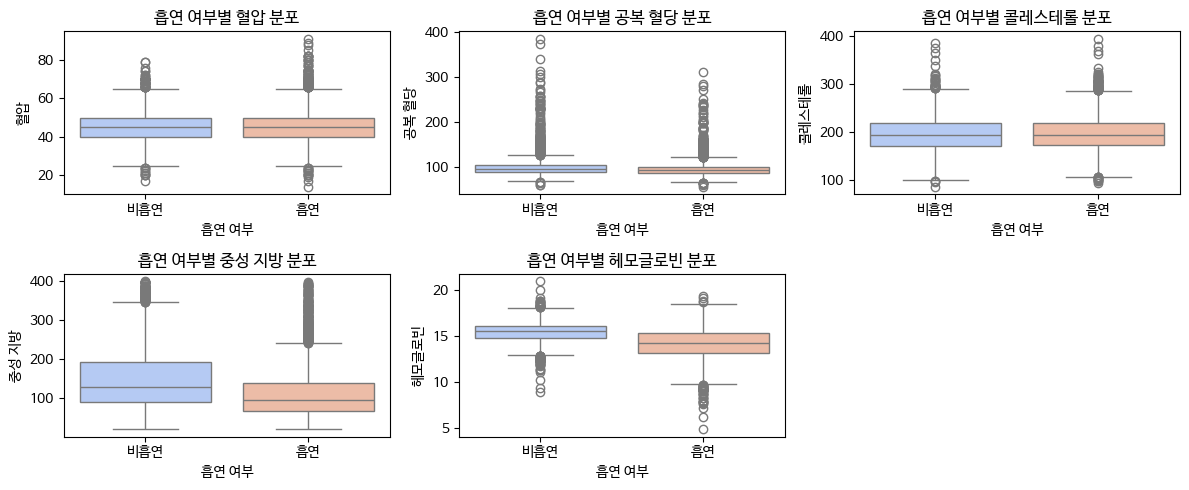

In [ ]:
# 박스플롯
plt.figure(figsize=(12, 5))
#1. 첫 번째 차트: 흡연 여부별 혈압 분포
plt.subplot(2,3,1)
sns.boxplot(data=health_data,
            x="흡연 여부",
            y="혈압",
            hue="흡연 여부",
            palette='coolwarm',
            legend=False)
plt.title("흡연 여부별 혈압 분포")
plt.xlabel('흡연 여부')
plt.ylabel('혈압')
plt.xticks([0, 1], ['비흡연', '흡연'])

#2. 두 번째 차트: 흡연 여부별 공복 혈당 분포
plt.subplot(2,3,2)
sns.boxplot(data=health_data,
            x="흡연 여부",
            y="공복 혈당",
            hue="흡연 여부",
            palette='coolwarm',
            legend=False)
plt.title("흡연 여부별 공복 혈당 분포")
plt.xlabel('흡연 여부')
plt.ylabel('공복 혈당')
plt.xticks([0, 1], ['비흡연', '흡연'])

#3. 세 번째 차트: 흡연 여부별 콜레스테롤 분포
plt.subplot(2,3,3)
sns.boxplot(data=health_data,
            x="흡연 여부",
            y="콜레스테롤",
            hue="흡연 여부",
            palette='coolwarm',
            legend=False)
plt.title("흡연 여부별 콜레스테롤 분포")
plt.xlabel('흡연 여부')
plt.ylabel('콜레스테롤')
plt.xticks([0, 1], ['비흡연', '흡연'])


#4. 네 번째 차트: 흡연 여부별 중성 지방 분포
plt.subplot(2,3,4)
sns.boxplot(data=health_data,
            x="흡연 여부",
            y="중성 지방",
            hue="흡연 여부",
            palette='coolwarm',
            legend=False)
plt.title("흡연 여부별 중성 지방 분포")
plt.xlabel('흡연 여부')
plt.ylabel('중성 지방')
plt.xticks([0, 1], ['비흡연', '흡연'])

#5. 다섯 번째 차트: 흡연 여부별 헤모글로빈 분포
plt.subplot(2,3,5)
sns.boxplot(data=health_data,
            x="흡연 여부",
            y="헤모글로빈",
            hue="흡연 여부",
            palette='coolwarm',
            legend=False)
plt.title("흡연 여부별 헤모글로빈 분포")
plt.xlabel('흡연 여부')
plt.ylabel('헤모글로빈')
plt.xticks([0, 1], ['비흡연', '흡연'])

plt.tight_layout()
plt.savefig('../images/01_eda/07_건강지표_비교.png', dpi=150, bbox_inches='tight')
plt.show()

# 나이대별+흡연여부별 혈압 분포

([<matplotlib.axis.XTick at 0x7a629d5a72f0>,
 [Text(0, 0, '비흡연'), Text(1, 0, '흡연')])

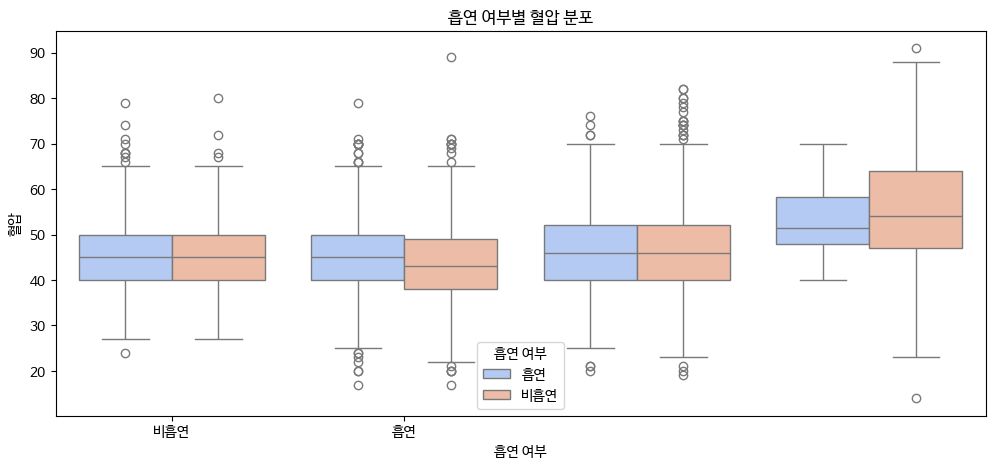

In [ ]:
# 박스플롯 - 다차원 비교
plt.figure(figsize=(12, 5))
# 나이대별+흡연여부별 혈압 박스플롯
sns.boxplot(data=health_data,
            x="나이대",
            y="혈압",
            hue="흡연 여부",
            palette='coolwarm',
            legend=True)
plt.title("흡연 여부별 혈압 분포")
plt.xlabel('흡연 여부')
plt.ylabel('혈압')
plt.xticks([0, 1], ['비흡연', '흡연'])
plt.savefig('../images/01_eda/08_나이대별_흡연여부_혈압.png', dpi=150, bbox_inches='tight')
plt.show()


#간 효소율과 '중성 지방'의 상관관계

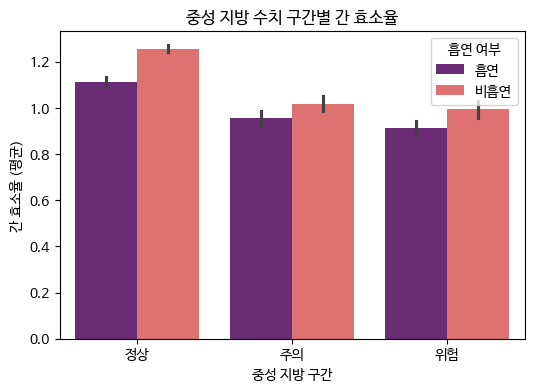

In [ ]:
#간 효소율과 '중성 지방'의 상관관계
plt.figure(figsize=(6,4))

sns.barplot(
    data=health_data,
    x=pd.cut(health_data['중성 지방'], bins=[0, 150, 200, 500], labels=['정상', '주의', '위험']),
    y="간 효소율",
    hue="흡연 여부",
    palette="magma"
)

plt.title("중성 지방 수치 구간별 간 효소율")
plt.xlabel("중성 지방 구간")
plt.ylabel("간 효소율 (평균)")

plt.savefig('../images/01_eda/09_중성지방_간효소율.png', dpi=150, bbox_inches='tight')
plt.show()

#간 효소율과 "BMI의 관계"

Text(0, 0.5, '인원 수')

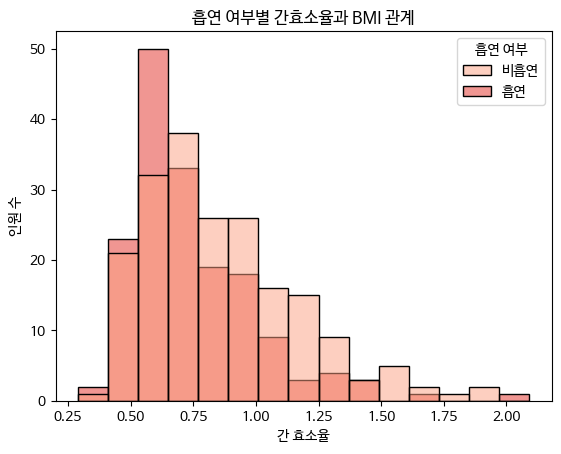

In [ ]:
#간 효소율과 "BMI의 관계"
overweight_df = health_data[health_data['BMI'] > 30]
sns.histplot(data=overweight_df, x='간 효소율',
            hue='흡연 여부',
            bins=15,
            palette='Reds')

plt.title('흡연 여부별 간효소율과 BMI 관계')
plt.xlabel('간 효소율')
plt.ylabel('인원 수')
plt.savefig('../images/01_eda/10_비만_간효소율.png', dpi=150, bbox_inches='tight')
plt.show()


# 흡연 여부에 따른 충치 환자 분포

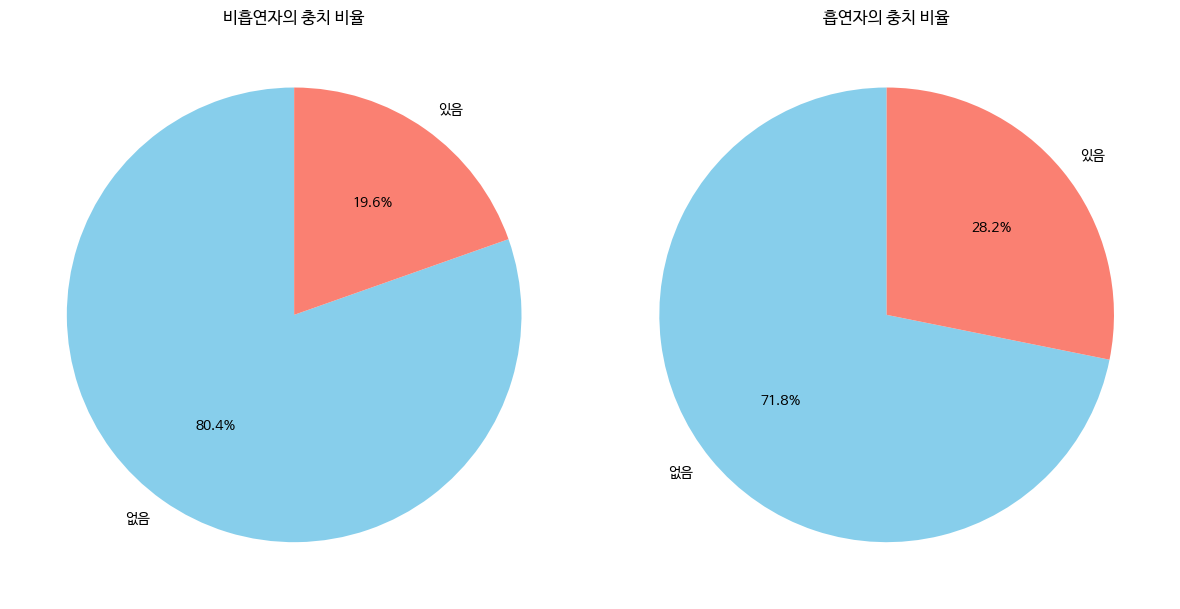

In [ ]:


# 1.흡연 여부로 나누기
smoke_0 = health_data[health_data['흡연 여부'] == '비흡연']['충치'].value_counts()
smoke_1 = health_data[health_data['흡연 여부'] == '흡연']['충치'].value_counts()

fig, ax = plt.subplots(1, 2, figsize=(12, 6))

# 왼쪽: 비흡연자 파이 차트
ax[0].pie(smoke_0, labels=['없음', '있음'], autopct='%1.1f%%', startangle=90, colors=['skyblue', 'salmon'])
ax[0].set_title('비흡연자의 충치 비율')

# 오른쪽: 흡연자 파이 차트
ax[1].pie(smoke_1, labels=['없음', '있음'], autopct='%1.1f%%', startangle=90, colors=['skyblue', 'salmon'])
ax[1].set_title('흡연자의 충치 비율')

plt.tight_layout()
plt.savefig('../images/01_eda/11_충치_비율.png', dpi=150, bbox_inches='tight')
plt.show()

# `흡연 여부에 따른 충치 환자의 혈당 수치`

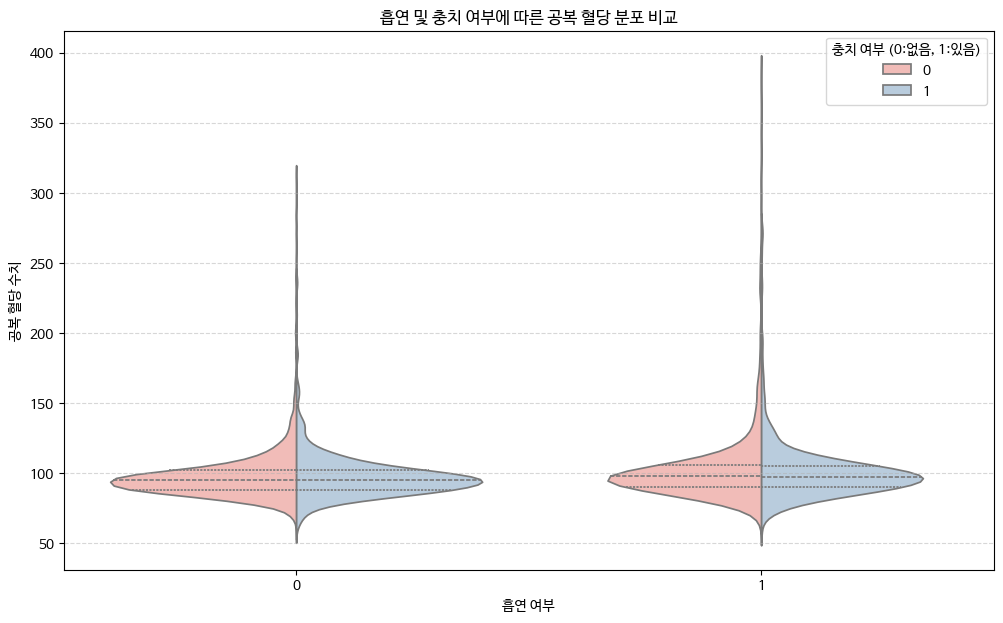

In [ ]:
plt.figure(figsize=(12, 7))


sns.violinplot(data=health_data, x='label', y='공복 혈당',
               hue='충치', palette='Pastel1', inner="quartile")

plt.title('흡연 및 충치 여부에 따른 공복 혈당 분포 비교')
plt.xlabel('흡연 여부')
plt.ylabel('공복 혈당 수치')
plt.legend(title='충치 여부 (0:없음, 1:있음)')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.savefig('../images/01_eda/12_충치_혈당_분포.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# 위 시각화를 통해 알게된 사실을 정리해봅시다.



# 1. 전반적인 건강 지표 비교

**혈압, 공복 혈당, 콜레스테롤**
 세 지표 모두 박스의 위치(중앙값)는 비흡연자와 흡연자 사이에 큰 차이가 없어 보임.
 **상단 이상치(Outliers)**를 보면 흡연자 그룹에서 혈압과 혈당이 비정상적으로 높은 사람들이 더 밀집되어 나타나는 경향이 있음

**중성 지방**
 데이터상으로는 오히려 비흡연자 그룹의 중위값이 조금 더 높아 보이는데, 이는 데이터셋의 연령대나 식습관 변수가 섞여 있을 가능성이 크다. 다만, 흡연자 그룹의 상단 꼬리가 매우 길어 고중성지방혈증 위험군이 존재함을 보여줍니다.

**헤모글로빈**
 비흡연자보다 흡연자 그룹의 헤모글로빈 수치 중앙값이 낮게 형성되어 있습니다. 보통 흡연은 수치를 높인다고 알려져 있는데, 이 데이터에서는 오히려 흡연군에서 빈혈 기여도가 높거나 영양 불균형이 있을 가능성을 시사함.

# 2. 나이대별 혈압의 변화
나이가 들어감에 따라 흡연의 영향이 어떻게 축적되는지 잘 보여줌.
청년층 vs 노년층: 청년층(-30)에서는 흡연 여부에 따른 혈압 차이가 크지 않지만, 노년층(70-)으로 갈수록 흡연자 그룹의 혈압 중앙값이 비흡연자보다 눈에 띄게 높아짐
흡연의 유해성이 단기적이기보다 연령이 높아짐에 따라 신체에 누적되어 혈압 조절 능력을 저하시킨다는 강력한 증거가 될 수 있다.

# 3. 고 위험군의 간 효소율과 BMI의 관계
그래프의 x축을 보면 1.25에서 2.00 사이의 높은 간 효소율 구간에 붉은색(흡연) 막대들이 드문드문 끝까지 이어져 있는 것을 볼 수 있다.
비만인 사람들 중에서도 흡연자 그룹에서 간 수치가 비정상적으로 높은 '고위험 이상치'가 더 빈번하게 발생함을 의미, 비만 자체가 간에 무리를 주지만, 흡연이 그 위험을 더 극단적으로 밀어붙인다고 볼 수 있다

#4. 상관관계 히트맵
흡연(label)과의 관계: **헤모글로빈(0.40)**과 **중성 지방(0.25)**이 흡연 여부와 가장 강한 양의 상관관계를 보인다.
흡연이 혈액 성분 변화와 지질 대사 이상에 직접적인 영향을 준다는 통계적 근거가 됨.

반면 혈압(0.02)은 전체 데이터 기준으로는 흡연과 직접적인 상관성이 낮게 나타나는데, 이는 앞선 박스플롯 분석처럼 '나이'와 같은 변수를 분리해서 보았을 때만 차이가 드러나는 특성 때문일 수 있다.

#5. 중성 지방 구간별 간 효소율
그래프상 '정상' 구간의 간 효소율 평균이 '위험' 구간보다 높게 나타나고 있음.
이는 데이터의 불균형(특정 구간에 샘플 수가 너무 적거나 극단적인 이상치가 포함됨) 때문일 수 있습니다. '위험' 구간에 해당하는 데이터 개수가 충분한지 확인이 필요해 보임.

# 6. 흡연 여부에 따른 나이대별 평균 혈당 비교
모든 연령대에서 흡연자의 혈당 우위로 나타남. 이는 나이와 상관없이 흡연이 공복 혈당 수치를 높이는 위험 인자로 작용하고 있음을 시사함.

노화에 따라 혈당 조절 능력이 저하되면서 평균 혈당이 자연스럽게 상승하는 경향을 보임.

노년그룹의 막대 상단의 오차 막대가 다른 그룹보다 훨씬 길게 나타남. 이는 노년층 흡연자 수가 적거나, 해당 그룹 내엥서 혈당 수치의 개인차가 매우 크다는것을 의미. 그럼에도 불고하고 평균치치는 가장 높아, 고령 흡연자의 당뇨 관리 필요성이 크다는 것을 시사함.

# 7. 흡연 여부에 따른 충치 비율
비흡연자의 충치 비율은 **19.6%**인 반면, 흡연자는 **28.2%**로 약 8.6%p 더 높다.
흡연이 구강 환경을 악화시켜 충치 발생 확률을 유의미하게 높인다.

# 8. 흡연 여부에 따른 충치 여부별 혈당 분포

흡연자 그룹의 바이올린 몸통이 미세하게 더 높은 혈당 수치에 위치함. 이는 충치 여부와 상관없이, 흡연을 하는 것만으로도 평균적인 공복 혈당 베이스라인이 높아진다는것을 의미한다.

**"흡연자이면서 충치까지 있는 경우"**가 혈당 상승에 가장 취약하며, 충치(구강 염증)의 악영향이 흡연자에게서 더 두드러지게 나타날 수 있음을 시사한다.

혈당 300~400 사이의 극단적인 고혈당 수치를 나타내는 꼬리가 흡연자 그룹, 특히 충치가 있는 쪽에서 가장 길고 뾰족하게 올라가 있다.
흡연과 충치가 결합될 때 당뇨 합병증이나 급격한 혈당 상승을 겪는 위험 인원이 발생할 확률이 가장 높다.

### "흡연은 단순히 단독 지표를 나쁘게 할 뿐만 아니라, 비만과 노화라는 신체적 약점과 결합했을 때 간 수치와 혈압을 폭발적으로 악화시키는 '위험 증폭제' 역할을 한다. 또한 구강 건강과 결합 했을 때 혈당 수치 상승시켜 대사 질환을 증폭시킬수 있다."

## 분석 요약 및 다음 단계

### EDA를 통해 확인한 주요 인사이트
- **헤모글로빈(r=0.40)과 중성지방(r=0.25)**이 흡연 여부와 가장 강한 상관관계를 보임
- 흡연자 충치 비율(28.2%) > 비흡연자(19.6%): 구강 건강과 흡연의 관련성 시사
- 나이가 높을수록 흡연자·비흡연자 간 혈압 격차가 커지는 경향 확인
- 비만(BMI > 30) 흡연자에서 간 효소율 극단적 이상치가 더 빈번하게 발생

### 다음 단계 → [`02_가설검정_이변량분석.ipynb`](02_가설검정_이변량분석.ipynb)
위 인사이트를 바탕으로 3가지 가설을 수립하고 통계적으로 검증합니다.

1. 흡연 여부에 따라 **BMI와 헤모글로빈** 수치는 유의미한 차이를 보일 것이다
2. 흡연 여부에 따라 **동맥경화 지수(AI)**는 유의미한 차이를 보일 것이다
3. 흡연자 집단 내 **충치 유무**에 따라 대사 지표(공복혈당, 간 효소율)의 차이가 존재할 것이다